In [1]:
from pybedtools import BedTool
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import pandas as pd 
import os
import seaborn as sns

# List of strains
strains = [
    "129S1_SvImJ",
    "AKR_J",
    "A_J",
    "BALB_cJ",
    "C3H_HeJ",
    "CAST_EiJ",
    "CBA_J",
    "DBA_2J",
    "FVB_NJ",
    "LP_J",  
    "NOD_ShiLtJ",
    "NZO_HlLtJ",  
    "PWK_PhJ",
    "SPRET_EiJ",
    "WSB_EiJ",
    "C57BL_6NJ",
    "C57BL_6"
]



cat replicate1.bed replicate2.bed replicate3.bed | sort -k1,1 -k2,2n | \
bedtools merge -c 4 -o distinct > merged_stage.bed


bedtools subtract -a merged_stage.bed -b other_stage1.bed -f 0.5 -r | \
bedtools subtract -a - -b other_stage2.bed -f 0.5 -r > unique_stage.bed

bedtools intersect -a merged_stage1.bed -b merged_stage2.bed -f 0.5 -r > shared_between_stages.bed

In [ ]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool

# Base path to files
base_path = "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio"



# Function to generate file paths for a strain
def get_file_paths(strain):
    return {
        "12.5dpp": [
            os.path.join(base_path, strain, f"{strain}-12.5dpp.{i}.bed") for i in range(1, 4)
        ],
        "16.5dpc": [
            os.path.join(base_path, strain, f"{strain}-16.5dpc.{i}.bed") for i in range(1, 4)
        ],
        "20.5dpp": [
            os.path.join(base_path, strain, f"{strain}-20.5dpp.{i}.bed") for i in range(1, 4)
        ],
    }

# Function to verify all files exist
def verify_files(file_paths):
    missing_files = [file for stage, files in file_paths.items() for file in files if not os.path.exists(file)]
    if missing_files:
        print(f"Missing files for {file_paths['12.5dpp'][0].split('/')[-2]}: {missing_files}")
    return len(missing_files) == 0

# Function to merge replicates
def merge_replicates_with_overlap(file_paths):
    bedtools_list = [BedTool(file) for file in file_paths]
    merged_bed = bedtools_list[0]
    for bed in bedtools_list[1:]:
        merged_bed = merged_bed.cat(bed, postmerge=False)
    return merged_bed.sort().merge(c=4, o="distinct")

# Function to calculate unique and shared clusters
def calculate_unique_shared(strain, file_paths):
    merged_12_5dpp = merge_replicates_with_overlap(file_paths["12.5dpp"])
    merged_16_5dpc = merge_replicates_with_overlap(file_paths["16.5dpc"])
    merged_20_5dpp = merge_replicates_with_overlap(file_paths["20.5dpp"])

    # Unique clusters
    unique_12_5dpp = merged_12_5dpp.subtract(merged_16_5dpc, f=0.5, r=True).subtract(merged_20_5dpp, f=0.5, r=True)
    unique_16_5dpc = merged_16_5dpc.subtract(merged_12_5dpp, f=0.5, r=True).subtract(merged_20_5dpp, f=0.5, r=True)
    unique_20_5dpp = merged_20_5dpp.subtract(merged_12_5dpp, f=0.5, r=True).subtract(merged_16_5dpc, f=0.5, r=True)

    # Shared clusters
    shared_clusters = merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True).intersect(merged_20_5dpp, f=0.5, r=True)

    # Save results
    results = {
        "Stage": ["12.5dpp", "16.5dpc", "20.5dpp", "Shared"],
        "Unique Clusters": [len(unique_12_5dpp), len(unique_16_5dpc), len(unique_20_5dpp), len(shared_clusters)],
    }
    df = pd.DataFrame(results)
    output_path = os.path.join(base_path, strain, f"{strain}_unique_shared_clusters.csv")
    df.to_csv(output_path, index=False)
    print(f"Results saved for {strain} at {output_path}")

    # Visualize Venn diagram
    venn3(
        subsets=(
            len(unique_12_5dpp), len(unique_16_5dpc), len(shared_clusters),
            len(unique_20_5dpp), 0, 0, 0
        ),
        set_labels=("12.5dpp", "16.5dpc", "20.5dpp"),
    )
    plt.title(f"Venn Diagram for {strain}")
    plt.savefig(os.path.join(base_path, strain, f"{strain}_venn_diagram.png"))
    plt.close()

# Main script
for strain in strains:
    file_paths = get_file_paths(strain)
    if verify_files(file_paths):
        calculate_unique_shared(strain, file_paths)
    else:
        print(f"Skipping {strain} due to missing files.")

Results saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_unique_shared_clusters.csv
Results saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_unique_shared_clusters.csv
Results saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_unique_shared_clusters.csv
Results saved for BALB_cJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/BALB_cJ/BALB_cJ_unique_shared_clusters.csv
Results saved for C3H_HeJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/C3H_HeJ/C3H_HeJ_unique_shared_clusters.csv
Results saved for CAST_EiJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/CAST_EiJ/CAST_EiJ_unique_shared_clusters.csv
Results

In [3]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool



# Function to generate file paths for a strain
def get_file_paths(strain):
    return {
        "12.5dpp": [
            os.path.join(base_path, strain, f"{strain}-12.5dpp.{i}.bed") for i in range(1, 4)
        ],
        "16.5dpc": [
            os.path.join(base_path, strain, f"{strain}-16.5dpc.{i}.bed") for i in range(1, 4)
        ],
        "20.5dpp": [
            os.path.join(base_path, strain, f"{strain}-20.5dpp.{i}.bed") for i in range(1, 4)
        ],
    }

# Function to verify all files exist
def verify_files(file_paths):
    missing_files = [file for stage, files in file_paths.items() for file in files if not Path(file).exists()]
    if missing_files:
        print(f"Missing files for {file_paths['12.5dpp'][0].split('/')[-2]}: {missing_files}")
    return len(missing_files) == 0

# Function to convert BED files into BedTool objects
def read_pirna_bedtool(file):
    return BedTool(file)

# Function to merge replicates
def merge_replicates_with_overlap(file_paths):
    bedtools_list = [read_pirna_bedtool(file) for file in file_paths]
    merged_bed = bedtools_list[0]
    for bed in bedtools_list[1:]:
        merged_bed = merged_bed.cat(bed, postmerge=False)
    # Use bedtools merge with strand aggregation
    return merged_bed.sort().merge(c=4, o="distinct")

# Function to calculate unique and shared clusters
def calculate_unique_shared(strain, file_paths):
    merged_12_5dpp = merge_replicates_with_overlap(file_paths["12.5dpp"])
    merged_16_5dpc = merge_replicates_with_overlap(file_paths["16.5dpc"])
    merged_20_5dpp = merge_replicates_with_overlap(file_paths["20.5dpp"])

    # Unique clusters
    unique_12_5dpp = merged_12_5dpp.subtract(merged_16_5dpc, f=0.5, r=True).subtract(merged_20_5dpp, f=0.5, r=True)
    unique_16_5dpc = merged_16_5dpc.subtract(merged_12_5dpp, f=0.5, r=True).subtract(merged_20_5dpp, f=0.5, r=True)
    unique_20_5dpp = merged_20_5dpp.subtract(merged_12_5dpp, f=0.5, r=True).subtract(merged_16_5dpc, f=0.5, r=True)

    # Shared clusters
    shared_clusters = merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True).intersect(merged_20_5dpp, f=0.5, r=True)

    # Save results
    results = {
        "Stage": ["12.5dpp", "16.5dpc", "20.5dpp", "Shared"],
        "Unique Clusters": [len(unique_12_5dpp), len(unique_16_5dpc), len(unique_20_5dpp), len(shared_clusters)],
    }
    df = pd.DataFrame(results)
    output_path = os.path.join(base_path, strain, f"{strain}_unique_shared_clusters.csv")
    df.to_csv(output_path, index=False)
    print(f"Results saved for {strain} at {output_path}")



for strain in strains:
    file_paths = get_file_paths(strain)
    if verify_files(file_paths):
        calculate_unique_shared(strain, file_paths)
    else:
        print(f"Skipping {strain} due to missing files.")

Results saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_unique_shared_clusters.csv
Results saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_unique_shared_clusters.csv
Results saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_unique_shared_clusters.csv


Results saved for BALB_cJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/BALB_cJ/BALB_cJ_unique_shared_clusters.csv
Results saved for C3H_HeJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/C3H_HeJ/C3H_HeJ_unique_shared_clusters.csv
Results saved for CAST_EiJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/CAST_EiJ/CAST_EiJ_unique_shared_clusters.csv
Results saved for CBA_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/CBA_J/CBA_J_unique_shared_clusters.csv
Results saved for DBA_2J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/DBA_2J/DBA_2J_unique_shared_clusters.csv
Results saved for FVB_NJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/FVB_NJ/FVB_NJ_unique_shared_clusters.csv
Results saved

In [4]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool



# Function to filter out non-existing files
def filter_existing_files(file_paths):
    filtered_paths = {}
    for stage, files in file_paths.items():
        existing_files = [file for file in files if Path(file).exists()]
        if existing_files:
            filtered_paths[stage] = existing_files
    return filtered_paths

# Function to generate file paths for a strain
def get_file_paths(strain):
    return {
        "12.5dpp": [
            os.path.join(base_path, strain, f"{strain}-12.5dpp.{i}.bed") for i in range(1, 4)
        ],
        "16.5dpc": [
            os.path.join(base_path, strain, f"{strain}-16.5dpc.{i}.bed") for i in range(1, 4)
        ],
        "20.5dpp": [
            os.path.join(base_path, strain, f"{strain}-20.5dpp.{i}.bed") for i in range(1, 4)
        ],
    }

# Function to merge replicates
def merge_replicates_with_overlap(file_paths):
    if not file_paths:
        return BedTool()
    bedtools_list = [BedTool(file) for file in file_paths]
    merged_bed = bedtools_list[0]
    for bed in bedtools_list[1:]:
        merged_bed = merged_bed.cat(bed, postmerge=False)
    return merged_bed.sort().merge(c=4, o="distinct")

# Function to calculate shared clusters
def calculate_shared_clusters(strain, file_paths):
    # Merge replicates for each stage
    merged_12_5dpp = merge_replicates_with_overlap(file_paths.get("12.5dpp", []))
    merged_16_5dpc = merge_replicates_with_overlap(file_paths.get("16.5dpc", []))
    merged_20_5dpp = merge_replicates_with_overlap(file_paths.get("20.5dpp", []))

    # Shared between two stages
    shared_12_16 = merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
    shared_12_20 = merged_12_5dpp.intersect(merged_20_5dpp, f=0.5, r=True)
    shared_16_20 = merged_16_5dpc.intersect(merged_20_5dpp, f=0.5, r=True)

    # Shared across all three stages
    shared_all = (
        merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
        .intersect(merged_20_5dpp, f=0.5, r=True)
    )

    # Save results
    results = {
        "Comparison": ["12.5dpp-16.5dpc", "12.5dpp-20.5dpp", "16.5dpc-20.5dpp", "All Three Stages"],
        "Shared Clusters": [
            len(shared_12_16),
            len(shared_12_20),
            len(shared_16_20),
            len(shared_all),
        ],
    }
    df = pd.DataFrame(results)
    output_path = os.path.join(base_path, strain, f"{strain}_shared_clusters.csv")
    df.to_csv(output_path, index=False)
    print(f"Shared clusters saved for {strain} at {output_path}")



# Main script
for strain in strains:
    file_paths = get_file_paths(strain)
    filtered_paths = filter_existing_files(file_paths)
    if filtered_paths:
        calculate_shared_clusters(strain, filtered_paths)
    else:
        print(f"Skipping {strain} due to missing files for all stages.")

Shared clusters saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_shared_clusters.csv
Shared clusters saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_shared_clusters.csv
Shared clusters saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_shared_clusters.csv
Shared clusters saved for BALB_cJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/BALB_cJ/BALB_cJ_shared_clusters.csv
Shared clusters saved for C3H_HeJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/C3H_HeJ/C3H_HeJ_shared_clusters.csv
Shared clusters saved for CAST_EiJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/CAST_EiJ/CAST_EiJ_shared_clusters.csv


Shared clusters saved for CBA_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/CBA_J/CBA_J_shared_clusters.csv
Shared clusters saved for DBA_2J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/DBA_2J/DBA_2J_shared_clusters.csv
Shared clusters saved for FVB_NJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/FVB_NJ/FVB_NJ_shared_clusters.csv
Shared clusters saved for LP_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/LP_J/LP_J_shared_clusters.csv
Shared clusters saved for NOD_ShiLtJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/NOD_ShiLtJ/NOD_ShiLtJ_shared_clusters.csv
Shared clusters saved for NZO_HlLtJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/NZO_HlLtJ/NZO_HlLtJ_shared_clusters.csv
Shar

In [5]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool
import matplotlib.pyplot as plt


# Function to generate file paths for a strain
def get_file_paths(strain):
    return {
        "12.5dpp": [
            os.path.join(base_path, strain, f"{strain}-12.5dpp.{i}.bed") for i in range(1, 4)
        ],
        "16.5dpc": [
            os.path.join(base_path, strain, f"{strain}-16.5dpc.{i}.bed") for i in range(1, 4)
        ],
        "20.5dpp": [
            os.path.join(base_path, strain, f"{strain}-20.5dpp.{i}.bed") for i in range(1, 4)
        ],
    }

# Function to filter out non-existing files
def filter_existing_files(file_paths):
    filtered_paths = {}
    for stage, files in file_paths.items():
        existing_files = [file for file in files if Path(file).exists()]
        if existing_files:
            filtered_paths[stage] = existing_files
    return filtered_paths

# Function to merge replicates
def merge_replicates_with_overlap(file_paths):
    if not file_paths:
        return BedTool()
    bedtools_list = [BedTool(file) for file in file_paths]
    merged_bed = bedtools_list[0]
    for bed in bedtools_list[1:]:
        merged_bed = merged_bed.cat(bed, postmerge=False)
    # Use bedtools merge with strand aggregation
    return merged_bed.sort().merge(c=4, o="distinct")

# Function to calculate shared clusters and generate plots
def calculate_shared_clusters_and_plot(strain, file_paths):
    # Merge replicates for each stage
    merged_12_5dpp = merge_replicates_with_overlap(file_paths.get("12.5dpp", []))
    merged_16_5dpc = merge_replicates_with_overlap(file_paths.get("16.5dpc", []))
    merged_20_5dpp = merge_replicates_with_overlap(file_paths.get("20.5dpp", []))

    # Shared between two stages
    shared_12_16 = merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
    shared_12_20 = merged_12_5dpp.intersect(merged_20_5dpp, f=0.5, r=True)
    shared_16_20 = merged_16_5dpc.intersect(merged_20_5dpp, f=0.5, r=True)

    # Shared across all three stages
    shared_all = (
        merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
        .intersect(merged_20_5dpp, f=0.5, r=True)
    )

    # Save results
    results = {
        "Comparison": ["12.5dpp-16.5dpc", "12.5dpp-20.5dpp", "16.5dpc-20.5dpp", "All Three Stages"],
        "Shared Clusters": [
            len(shared_12_16),
            len(shared_12_20),
            len(shared_16_20),
            len(shared_all),
        ],
    }
    df = pd.DataFrame(results)
    output_path_csv = os.path.join(base_path, strain, f"{strain}_shared_clusters.csv")
    df.to_csv(output_path_csv, index=False)
    print(f"Shared clusters saved for {strain} at {output_path_csv}")

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.bar(df["Comparison"], df["Shared Clusters"], color=["#FF9999", "#66B2FF", "#99FF99", "#FFD700"])
    plt.title(f"Shared piRNA Clusters for {strain}", fontsize=16)
    plt.xlabel("Comparison", fontsize=14)
    plt.ylabel("Number of Shared Clusters", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    # Save plot
    output_path_plot = os.path.join(base_path, strain, f"{strain}_shared_clusters_plot.png")
    plt.savefig(output_path_plot)
    plt.close()
    print(f"Shared clusters plot saved for {strain} at {output_path_plot}")



# Main script
for strain in strains:
    file_paths = get_file_paths(strain)
    filtered_paths = filter_existing_files(file_paths)
    if filtered_paths:
        calculate_shared_clusters_and_plot(strain, filtered_paths)
    else:
        print(f"Skipping {strain} due to missing files for all stages.")

Shared clusters saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_shared_clusters.csv
Shared clusters plot saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_shared_clusters_plot.png
Shared clusters saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_shared_clusters.csv
Shared clusters plot saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_shared_clusters_plot.png
Shared clusters saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_shared_clusters.csv
Shared clusters plot saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_share

In [6]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool
import matplotlib.pyplot as plt



# Function to generate file paths for a strain
def get_file_paths(strain):
    return {
        "12.5dpp": [
            os.path.join(base_path, strain, f"{strain}-12.5dpp.{i}.bed") for i in range(1, 4)
        ],
        "16.5dpc": [
            os.path.join(base_path, strain, f"{strain}-16.5dpc.{i}.bed") for i in range(1, 4)
        ],
        "20.5dpp": [
            os.path.join(base_path, strain, f"{strain}-20.5dpp.{i}.bed") for i in range(1, 4)
        ],
    }

# Function to filter out non-existing files
def filter_existing_files(file_paths):
    filtered_paths = {}
    for stage, files in file_paths.items():
        existing_files = [file for file in files if Path(file).exists()]
        if existing_files:
            filtered_paths[stage] = existing_files
    return filtered_paths

# Function to merge replicates
def merge_replicates_with_overlap(file_paths):
    if not file_paths:
        return BedTool()
    bedtools_list = [BedTool(file) for file in file_paths]
    merged_bed = bedtools_list[0]
    for bed in bedtools_list[1:]:
        merged_bed = merged_bed.cat(bed, postmerge=False)
    return merged_bed.sort().merge(c=4, o="distinct")

# Function to calculate unique and shared clusters and generate plots
def calculate_unique_shared_clusters_and_plot(strain, file_paths):
    # Merge replicates for each stage
    merged_12_5dpp = merge_replicates_with_overlap(file_paths.get("12.5dpp", []))
    merged_16_5dpc = merge_replicates_with_overlap(file_paths.get("16.5dpc", []))
    merged_20_5dpp = merge_replicates_with_overlap(file_paths.get("20.5dpp", []))

    # Unique clusters
    unique_12_5dpp = (
        merged_12_5dpp.subtract(merged_16_5dpc, f=0.5, r=True)
        .subtract(merged_20_5dpp, f=0.5, r=True)
    )
    unique_16_5dpc = (
        merged_16_5dpc.subtract(merged_12_5dpp, f=0.5, r=True)
        .subtract(merged_20_5dpp, f=0.5, r=True)
    )
    unique_20_5dpp = (
        merged_20_5dpp.subtract(merged_12_5dpp, f=0.5, r=True)
        .subtract(merged_16_5dpc, f=0.5, r=True)
    )

    # Shared clusters
    shared_12_16 = merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
    shared_12_20 = merged_12_5dpp.intersect(merged_20_5dpp, f=0.5, r=True)
    shared_16_20 = merged_16_5dpc.intersect(merged_20_5dpp, f=0.5, r=True)
    shared_all = (
        merged_12_5dpp.intersect(merged_16_5dpc, f=0.5, r=True)
        .intersect(merged_20_5dpp, f=0.5, r=True)
    )

    # Save results
    results = {
        "Comparison": [
            "Unique (12.5dpp)", "Unique (16.5dpc)", "Unique (20.5dpp)",
            "12.5dpp-16.5dpc", "12.5dpp-20.5dpp", "16.5dpc-20.5dpp", "All Three Stages"
        ],
        "Cluster Counts": [
            len(unique_12_5dpp), len(unique_16_5dpc), len(unique_20_5dpp),
            len(shared_12_16), len(shared_12_20), len(shared_16_20), len(shared_all)
        ],
    }
    df = pd.DataFrame(results)
    output_path_csv = os.path.join(base_path, strain, f"{strain}_unique_shared_clusters.csv")
    df.to_csv(output_path_csv, index=False)
    print(f"Results saved for {strain} at {output_path_csv}")

    # Plot results
    plt.figure(figsize=(12, 8))
    colors = ["#FF9999", "#66B2FF", "#99FF99", "#FFD700", "#FFB6C1", "#87CEFA", "#90EE90"]
    plt.bar(df["Comparison"], df["Cluster Counts"], color=colors)
    plt.title(f"Unique and Shared piRNA Clusters for {strain}", fontsize=16)
    plt.xlabel("Comparison", fontsize=14)
    plt.ylabel("Number of Clusters", fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    # Save plot
    output_path_plot = os.path.join(base_path, strain, f"{strain}_unique_shared_clusters_plot.png")
    plt.savefig(output_path_plot)
    plt.close()
    print(f"Plot saved for {strain} at {output_path_plot}")



# Main script
for strain in strains:
    file_paths = get_file_paths(strain)
    filtered_paths = filter_existing_files(file_paths)
    if filtered_paths:
        calculate_unique_shared_clusters_and_plot(strain, filtered_paths)
    else:
        print(f"Skipping {strain} due to missing files for all stages.")

Results saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_unique_shared_clusters.csv
Plot saved for 129S1_SvImJ at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/129S1_SvImJ/129S1_SvImJ_unique_shared_clusters_plot.png
Results saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_unique_shared_clusters.csv
Plot saved for AKR_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/AKR_J/AKR_J_unique_shared_clusters_plot.png
Results saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_unique_shared_clusters.csv
Plot saved for A_J at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/A_J/A_J_unique_shared_clusters_plot.png
Results sa

In [7]:
from matplotlib import rcParams
from cycler import cycler
# Set global figure parameters for readability and aesthetics
rcParams['axes.facecolor'] = 'white'  # White panel background
rcParams['figure.facecolor'] = 'white'  # White figure background
rcParams['axes.grid'] = False  # No grid lines
rcParams['font.size'] = 12  # Consistent font size
rcParams['axes.labelcolor'] = 'white'  # Black axis labels
rcParams['xtick.color'] = 'white'  # Black tick labels
rcParams['ytick.color'] = 'white'  # Black tick labels
rcParams['legend.edgecolor'] = 'white'  # Black legend edges
rcParams['legend.frameon'] = False  # No box around the legend
rcParams['axes.prop_cycle'] = cycler(color=["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02", "#a6761d"])




# Collect data for all strains
summary_data = []
for strain in strains:
    result_file = os.path.join(base_path, strain, f"{strain}_unique_shared_clusters.csv")
    if os.path.exists(result_file):
        df = pd.read_csv(result_file)
        counts = df["Cluster Counts"].values
        summary_data.append([strain] + list(counts))



# Rearrange the collected data according to the desired order
columns = [
    "Strain", "Unique (12.5dpp)", "Unique (16.5dpc)", "Unique (20.5dpp)",
    "12.5dpp-16.5dpc", "12.5dpp-20.5dpp", "16.5dpc-20.5dpp", "All Three Stages"
]
combined_df = pd.DataFrame(summary_data, columns=columns)
combined_df

,Strain,Unique (12.5dpp),Unique (16.5dpc),Unique (20.5dpp),12.5dpp-16.5dpc,12.5dpp-20.5dpp,16.5dpc-20.5dpp,All Three Stages
0,129S1_SvImJ,5571,3966,1107,1222,211,175,119
1,AKR_J,5547,4239,1021,1259,207,177,124
2,A_J,5455,4206,1214,1399,320,258,178
3,BALB_cJ,5320,4233,1647,1130,486,383,274
4,C3H_HeJ,5382,3094,1059,1130,224,200,132
5,CAST_EiJ,5458,3646,1778,1012,576,491,314
6,CBA_J,5924,3535,1293,1227,330,249,162
7,DBA_2J,5990,4608,1064,1503,271,228,146
8,FVB_NJ,5700,4515,1284,1299,276,256,165
9,LP_J,6052,4608,1142,1392,238,225,143


In [8]:
desired_order = [
    "Strain", "Unique (16.5dpc)", "Unique (12.5dpp)", "Unique (20.5dpp)",
    "12.5dpp-16.5dpc", "16.5dpc-20.5dpp", "12.5dpp-20.5dpp", "All Three Stages"
]
combined_df = combined_df[desired_order]

Combined data saved at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/combined_unique_shared_clusters.csv


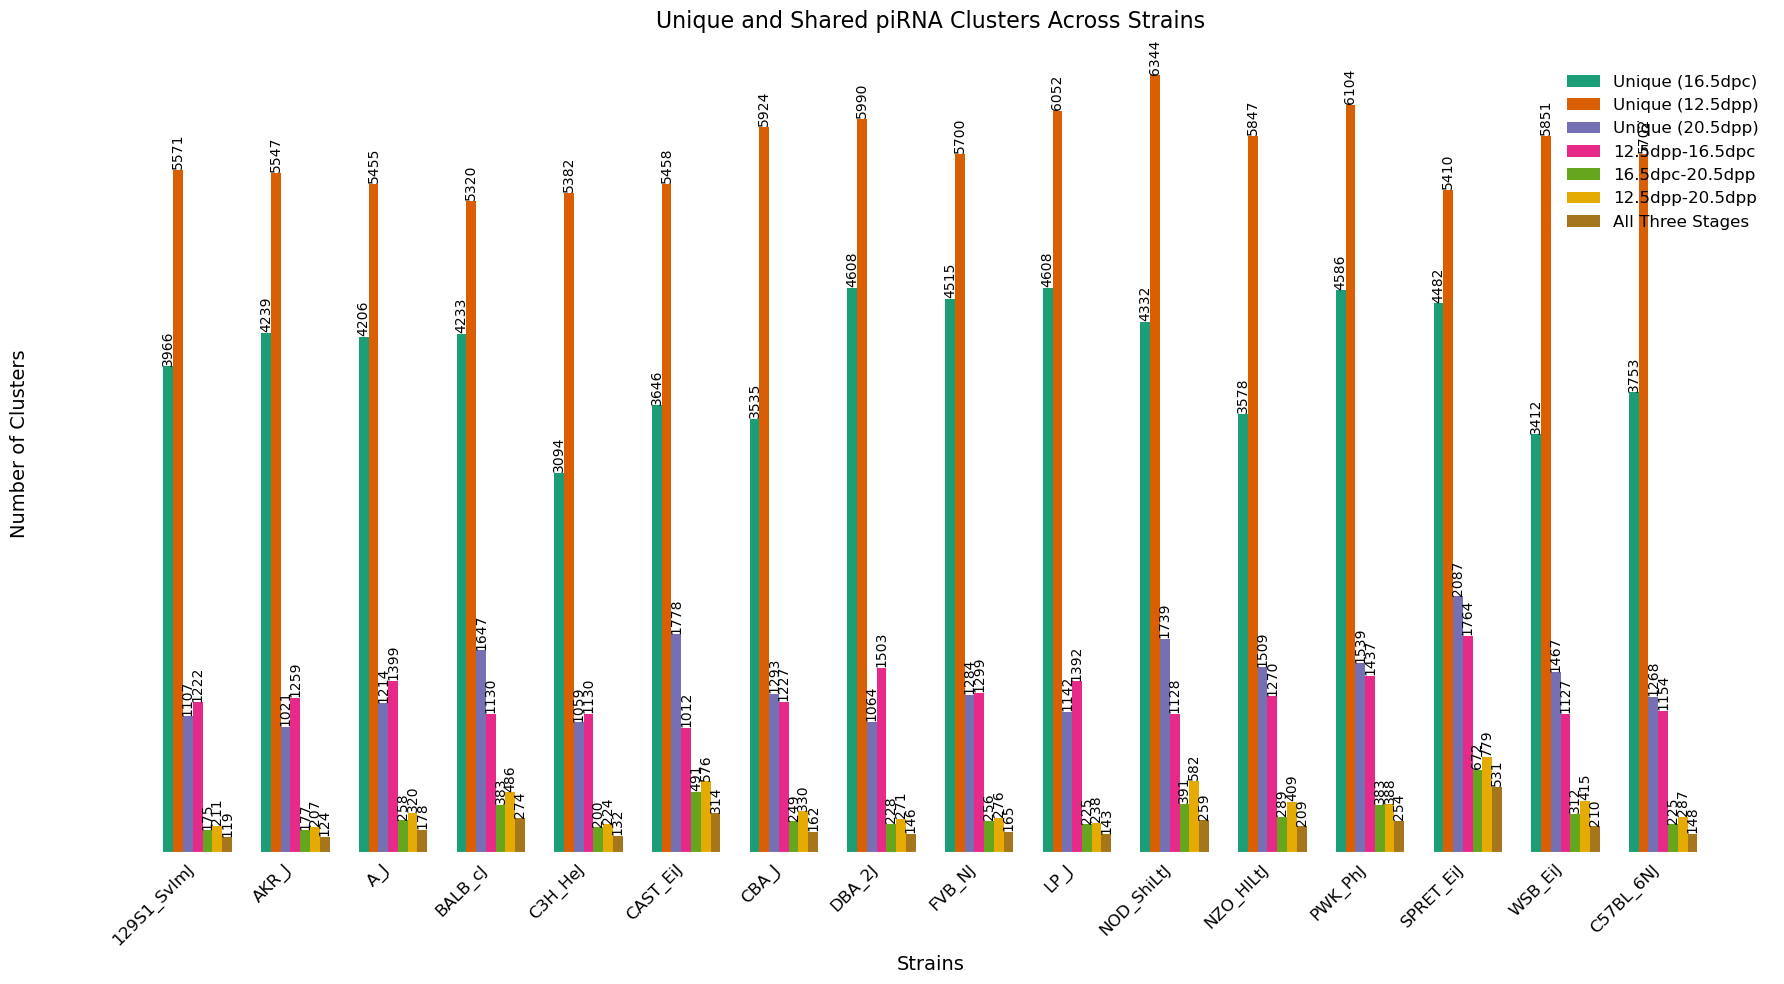

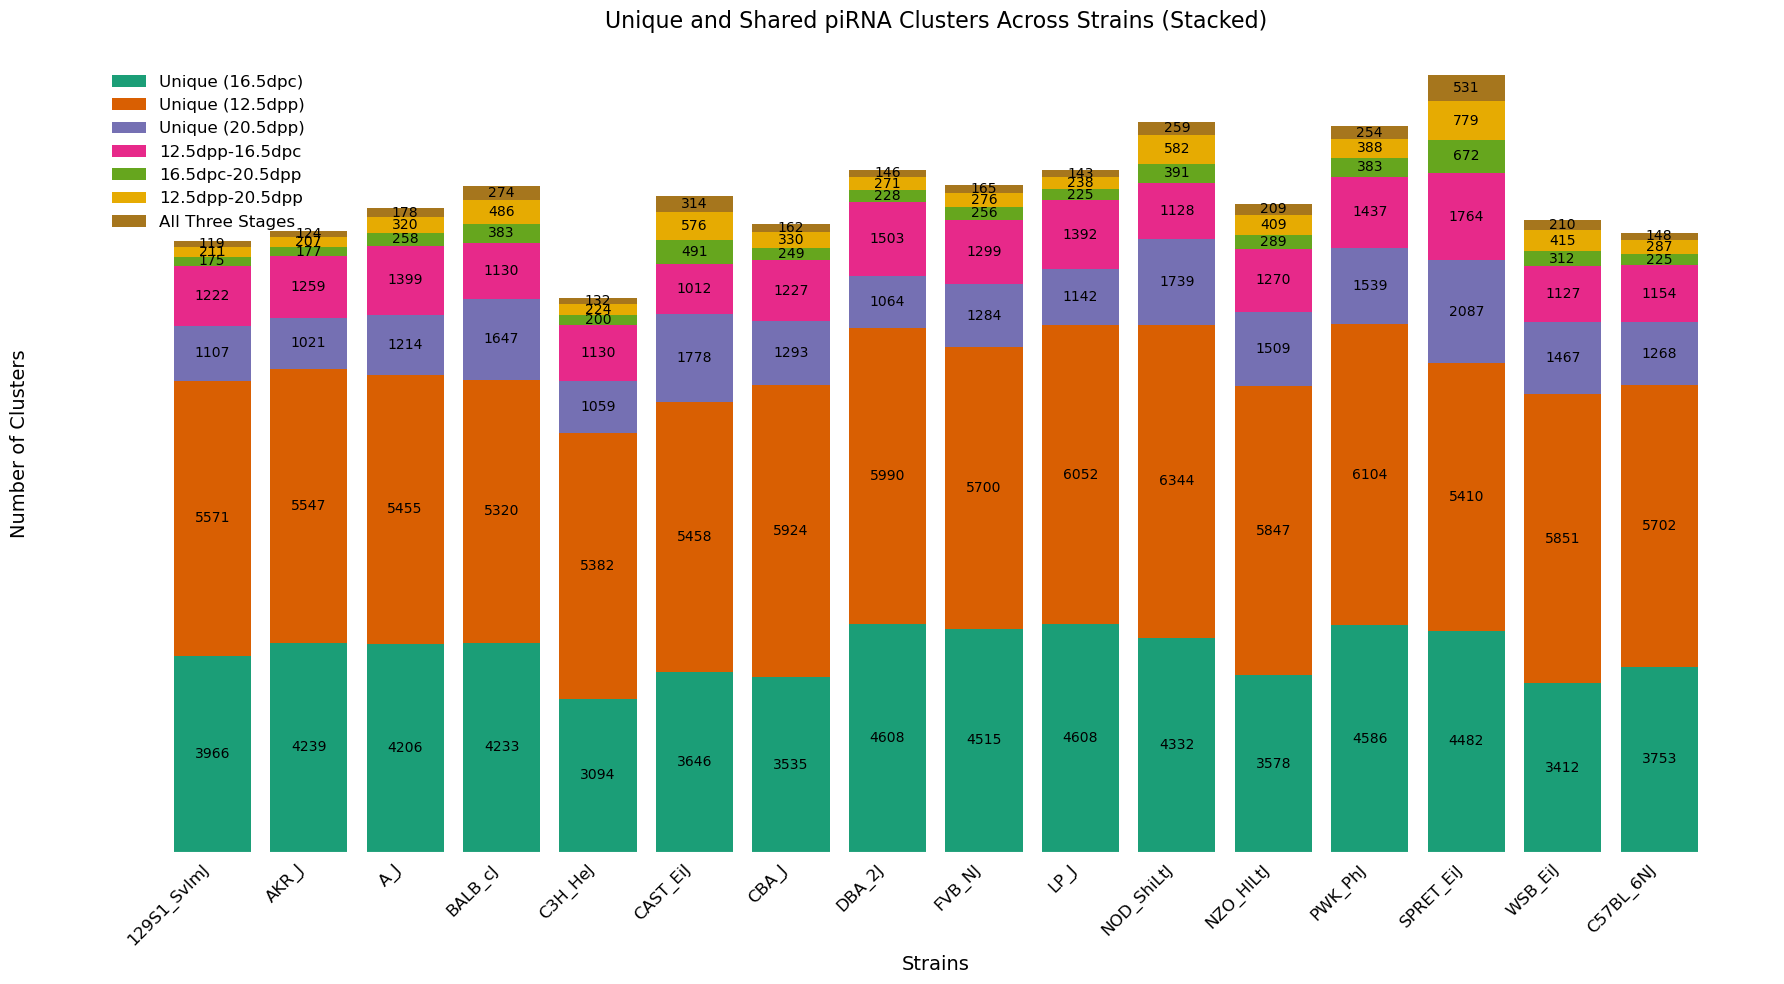

Grouped bar plot saved at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/combined_unique_shared_clusters_grouped.png
Stacked bar plot saved at //mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/filtred_final_Precurosrs/pacBio/combined_unique_shared_clusters_stacked.png


In [9]:
import numpy as np
# Set default plot size for all plots
rcParams['figure.figsize'] = (5, 5)  # Width, Height in inches
# Save the combined data to a single CSV file
combined_csv_path = os.path.join(base_path, "combined_unique_shared_clusters.csv")
combined_df.to_csv(combined_csv_path, index=False)
print(f"Combined data saved at {combined_csv_path}")

# Plot a grouped bar plot
plt.figure(figsize=(18, 10))
x = np.arange(len(combined_df))  # Positions for strains
bar_width = 0.1

# Bar positions for each category
categories = desired_order[1:]
offsets = np.linspace(-3*bar_width, 3*bar_width, len(categories))

for i, (category, offset) in enumerate(zip(categories, offsets)):
    bars = plt.bar(
        x + offset, combined_df[category], width=bar_width,
        label=category
    )
    # Add rotated labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label non-zero bars
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 5,
                f"{int(height)}",
                ha='center', va='bottom', rotation=90, fontsize=10, color='black'
            )

plt.xticks(x, combined_df["Strain"], rotation=45, ha="right", fontsize=12, color='black')
plt.xlabel("Strains", fontsize=14, color='black')
plt.ylabel("Number of Clusters", fontsize=14, color='black')
plt.title("Unique and Shared piRNA Clusters Across Strains", fontsize=16, color='black')
plt.legend(title="Cluster Type", fontsize=12, title_fontsize=12, labelcolor='black')
plt.tight_layout()

# Save the grouped bar plot
output_grouped_path = os.path.join(base_path, "combined_unique_shared_clusters_grouped.png")
plt.savefig(output_grouped_path)
plt.show()

# Plot a stacked bar plot
plt.figure(figsize=(18, 10))
x = np.arange(len(combined_df))  # Positions for strains
bottom = np.zeros(len(combined_df))

for i, category in enumerate(categories):
    bars = plt.bar(
        x, combined_df[category], bottom=bottom, label=category
    )
    # Add rotated labels on top of each stacked segment
    for bar, btm in zip(bars, bottom):
        height = bar.get_height()
        if height > 0:  # Only label non-zero bars
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                btm + height / 2,
                f"{int(height)}",
                ha='center', va='center', rotation=0, fontsize=10, color='black'
            )
    bottom += combined_df[category]

plt.xticks(x, combined_df["Strain"], rotation=45, ha="right", fontsize=12, color='black')
plt.xlabel("Strains", fontsize=14, color='black')
plt.ylabel("Number of Clusters", fontsize=14, color='black')
plt.title("Unique and Shared piRNA Clusters Across Strains (Stacked)", fontsize=16, color='black')
plt.legend(title="Cluster Type", fontsize=12, title_fontsize=12, labelcolor='black')
plt.tight_layout()

# Save the stacked bar plot
output_stacked_path = os.path.join(base_path, "combined_unique_shared_clusters_stacked.png")
plt.savefig(output_stacked_path)
plt.show()

print(f"Grouped bar plot saved at {output_grouped_path}")
print(f"Stacked bar plot saved at {output_stacked_path}")


In [10]:
import os
from pathlib import Path
import pandas as pd
from pybedtools import BedTool


stages = ["12.5dpp", "16.5dpc", "20.5dpp"]

# Collect length distributions
length_data = []

for strain in strains:
    for stage in stages:
        bed_file = os.path.join(base_path, strain, f"{strain}-{stage}.bed")
        if os.path.exists(bed_file):
            # Read bed file and compute lengths
            bed_df = pd.read_csv(bed_file, sep="\t", header=None, names=["chrom", "start", "end", "strand"])
            bed_df["length"] = bed_df["end"] - bed_df["start"]
            bed_df["Strain"] = strain
            bed_df["Stage"] = stage
            length_data.append(bed_df[["Strain", "Stage", "length"]])

# Combine all length data into a single DataFrame
length_df = pd.concat(length_data, ignore_index=True)

# Plot a box plot of piRNA cluster lengths
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=length_df,
    x="Stage",
    y="length",
    hue="Strain",
    showfliers=False,  # Optional: Hide outliers for better visualization
    palette="tab20"  # Color palette for the strains
)
plt.title("piRNA Cluster Length Distributions Across Stages and Strains", fontsize=16)
plt.xlabel("Developmental Stage", fontsize=14)
plt.ylabel("Cluster Length (bp)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Strain", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Save the plot
boxplot_path = os.path.join(base_path, "piRNA_cluster_length_distributions_boxplot.png")
plt.savefig(boxplot_path)
plt.show()

print(f"Box plot saved at {boxplot_path}")


ValueError: No objects to concatenate